In [21]:

import pandas as pd

df = pd.read_csv(
    "exchange_rate.csv",
    parse_dates=["date"]
)

df.head()

,date,Ex_rate
0,01-01-1990 00:00,0.7855
1,02-01-1990 00:00,0.7818
2,03-01-1990 00:00,0.7867
3,04-01-1990 00:00,0.7860
4,05-01-1990 00:00,0.7849


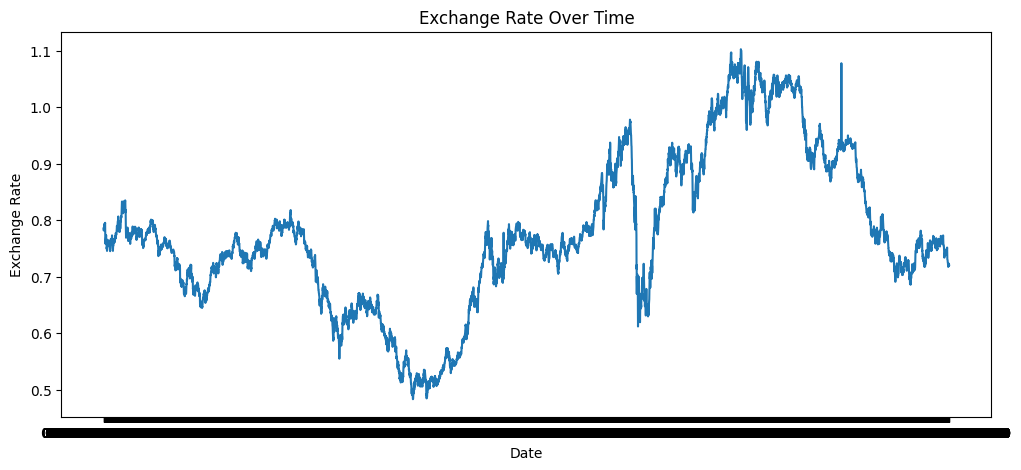

In [22]:
# Plot exchange rate time series

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df["date"],
    df["Ex_rate"]
)

plt.title("Exchange Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.show()

In [23]:
df.isnull().sum()

,0
date,0
Ex_rate,0


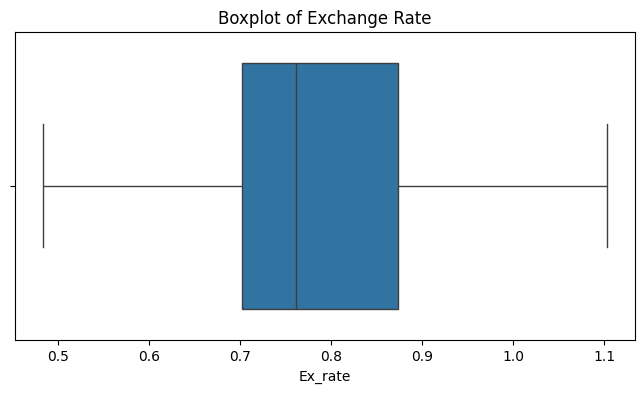

In [24]:
# Boxplot to identify anomalies/outliers

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.boxplot(x=df["Ex_rate"])

plt.title("Boxplot of Exchange Rate")
plt.show()

In [25]:
# Augmented Dickey-Fuller Test
# Used to check whether the time series is stationary

from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Ex_rate"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -1.6649941807382342
p-value : 0.4492327353597477


<Figure size 1200x500 with 0 Axes>

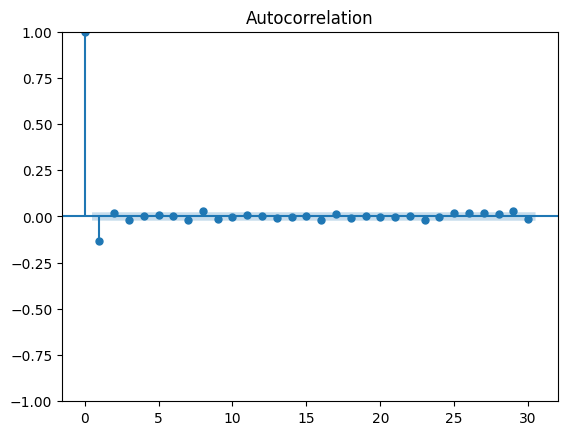

<Figure size 1200x500 with 0 Axes>

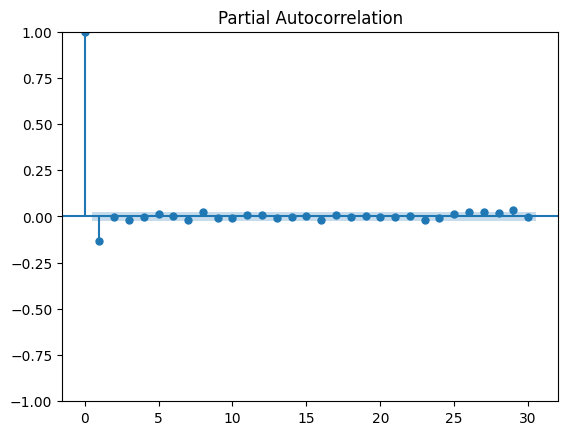

In [26]:
# ACF and PACF plots for ARIMA parameter selection

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# First differencing because d = 1

diff_series = df["Ex_rate"].diff().dropna()

plt.figure(figsize=(12,5))
plot_acf(diff_series, lags=30)
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(diff_series, lags=30)
plt.show()

In [37]:
# Split data into train and test sets

train_size = int(len(df) * 0.8)

train = df["Ex_rate"][:train_size]
test = df["Ex_rate"][train_size:]


# Fit ARIMA(1,1,1)

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    train,
    order=(1,1,1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Mon, 15 Jun 2026   AIC                         -45432.092
Time:                        16:37:06   BIC                         -45411.959
Sample:                             0   HQIC                        -45425.104
                               - 6070                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

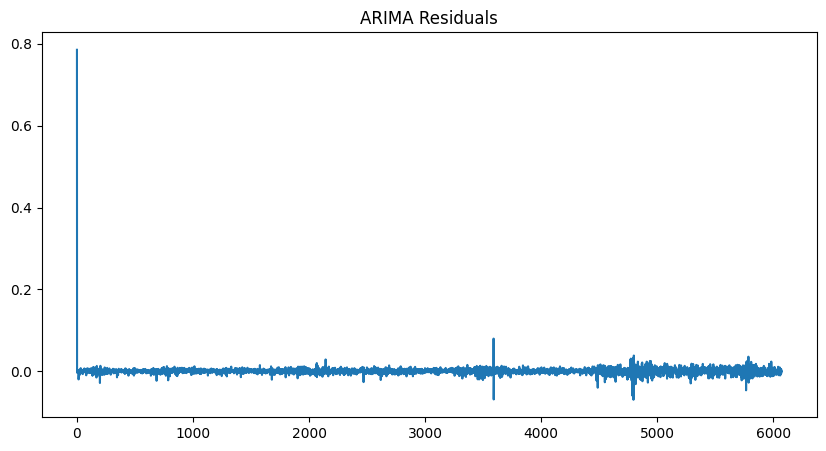

In [28]:
# Residual Diagnostics

residuals = arima_result.resid

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(residuals)

plt.title("ARIMA Residuals")

plt.show()

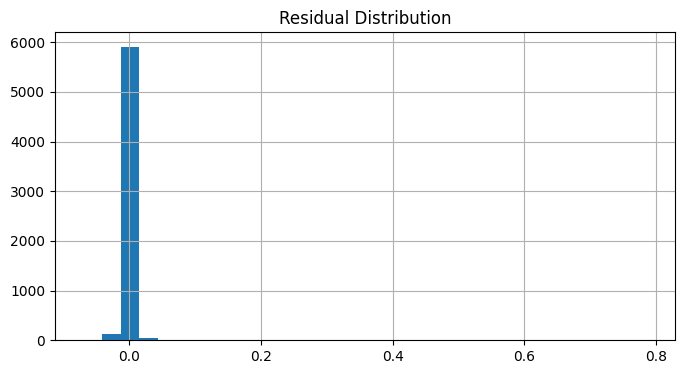

In [29]:
# Residual Distribution

residuals.hist(
    bins=30,
    figsize=(8,4)
)

plt.title("Residual Distribution")

plt.show()

In [30]:
# Forecast on test data

forecast = arima_result.forecast(
    steps=len(test)
)

print(forecast.head())

6070    1.023685
6071    1.023606
6072    1.023653
6073    1.023625
6074    1.023642
Name: predicted_mean, dtype: float64


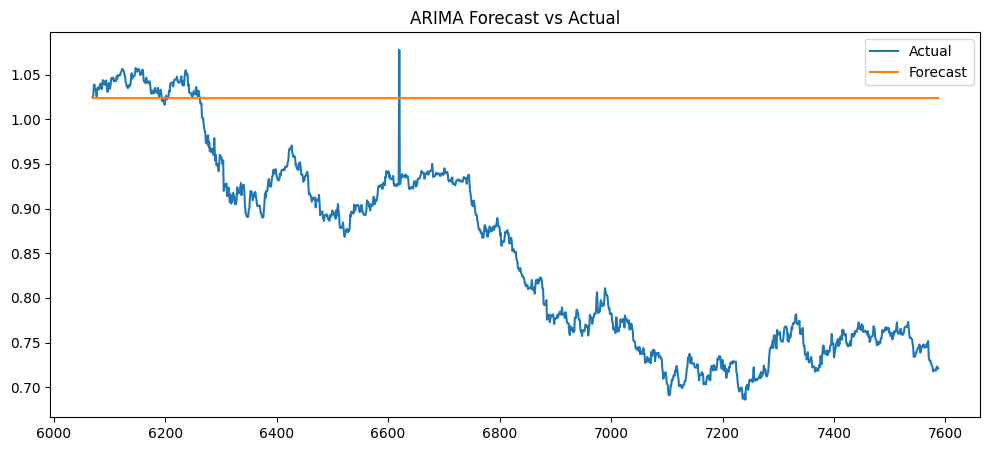

In [31]:
# Plot Actual vs Forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    forecast,
    label="Forecast"
)

plt.title("ARIMA Forecast vs Actual")
plt.legend()

plt.show()

In [32]:
# Exponential Smoothing Model

from statsmodels.tsa.holtwinters import ExponentialSmoothing

exp_model = ExponentialSmoothing(
    train,
    trend="add"
)

exp_fit = exp_model.fit()

exp_forecast = exp_fit.forecast(
    len(test)
)

print(exp_forecast.head())

6070    1.023582
6071    1.023621
6072    1.023661
6073    1.023700
6074    1.023739
dtype: float64


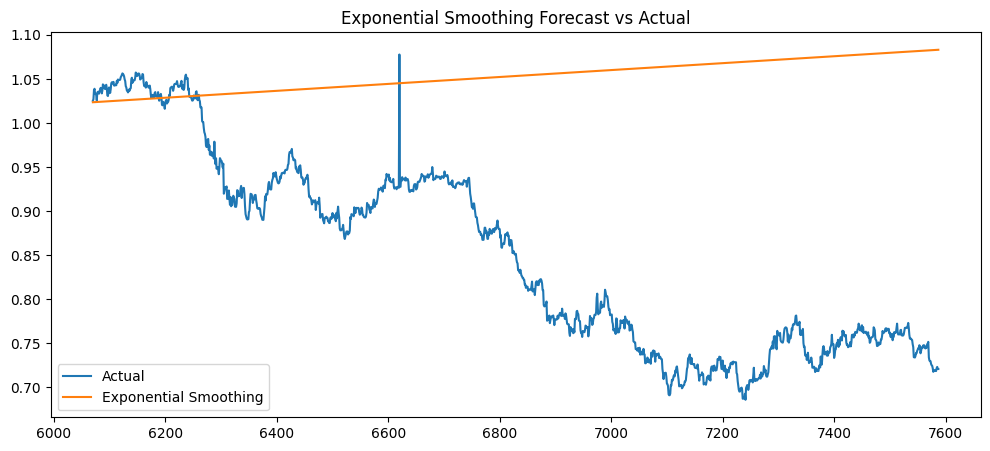

In [33]:
# Actual vs Exponential Smoothing Forecast

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    exp_forecast,
    label="Exponential Smoothing"
)

plt.title(
    "Exponential Smoothing Forecast vs Actual"
)

plt.legend()

plt.show()

In [34]:
# Calculate Error Metrics for ARIMA and Exponential Smoothing

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

# ARIMA Metrics

arima_mae = mean_absolute_error(
    test,
    forecast
)

arima_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

arima_mape = np.mean(
    np.abs(
        (test - forecast) / test
    )
) * 100


print("ARIMA MAE :", arima_mae)
print("ARIMA RMSE :", arima_rmse)
print("ARIMA MAPE :", arima_mape)

ARIMA MAE : 0.17770970449121345
ARIMA RMSE : 0.2054366965966928
ARIMA MAPE : 22.797966173811552


In [35]:
# Exponential Smoothing Metrics

exp_mae = mean_absolute_error(
    test,
    exp_forecast
)

exp_rmse = np.sqrt(
    mean_squared_error(
        test,
        exp_forecast
    )
)

exp_mape = np.mean(
    np.abs(
        (test - exp_forecast) / test
    )
) * 100

print("Exponential Smoothing MAE :", exp_mae)
print("Exponential Smoothing RMSE :", exp_rmse)
print("Exponential Smoothing MAPE :", exp_mape)

Exponential Smoothing MAE : 0.20659619114093827
Exponential Smoothing RMSE : 0.23910443161792286
Exponential Smoothing MAPE : 26.50866379878783


**Model Comparison**

Both ARIMA and Exponential Smoothing models were used to forecast exchange rates. The performance of the models was compared using MAE, RMSE, and MAPE.

The ARIMA model produced lower error values (MAE = 0.1777, RMSE = 0.2054, MAPE = 22.80%) compared to the Exponential Smoothing model (MAE = 0.2066, RMSE = 0.2391, MAPE = 26.51%).

Since lower error values indicate better forecasting performance, ARIMA performed better than Exponential Smoothing for this dataset.


**ARIMA Model**

Performance:
The ARIMA model gave the lowest MAE, RMSE, and MAPE values among the two models. This shows that its forecasts were closer to the actual exchange rate values.

Advantages:

* Provides good forecasting accuracy.
* Can model patterns present in time series data.

Limitations:

* Requires the data to be stationary.
* Selection of p, d, and q parameters can be time-consuming.


**Exponential Smoothing Model**

Performance:
The Exponential Smoothing model generated higher error values compared to ARIMA. Therefore, its forecasts were less accurate for this dataset.

Advantages:

* Requires less parameter tuning.
* Useful for capturing overall trends in data.

Limitations:

* Produced higher forecasting errors in this analysis.
* Less accurate than ARIMA for the exchange rate dataset.



**Conclusion**

The exchange rate dataset was analyzed using ARIMA and Exponential Smoothing models. The models were evaluated using MAE, RMSE, and MAPE.

Based on the observed results, ARIMA achieved lower error values and provided more accurate forecasts than Exponential Smoothing.

Therefore, ARIMA was found to be the better model for forecasting exchange rates in this dataset.
